### Sensor Data Analytics Mini Project
### Title: Anomaly Detection in Industrial Sensor Data Using Machine Learning
#### Author-  Aditya Kumar Roy

####**Methodology and Reliability**

The study applied a machine learning–based approach to detect abnormal patterns in motor sensor data. After preprocessing and scaling the dataset, *anomaly detection was performed using Isolation Forest, which identifies unusual observations by isolating data points that differ significantly from the majority. To improve interpretability, a Decision Tree model was used to analyze the detected anomalies and determine the most influential features.*

The **reliability of this methodology lies in its ability to detect anomalies without requiring labeled data and to provide interpretable insights through feature importance analysis.** By combining anomaly detection with an explainable model, the approach offers a dependable framework for identifying abnormal operating conditions and supporting predictive maintenance in industrial systems.

In [ ]:
## importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## Load the dataset
## Source: https://www.kaggle.com/code/jocelyndumlao/pmsm-regression-analysis

data = pd.read_csv("measures_v2.csv")

df = data # making a copy
data.head()


,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17


#### Data Pre-Processing

In [ ]:
## checking the dimension and columns in data
print("Shape of data:",data.shape)

print("\n Columns: ",data.columns)

## the target variable is = 'pm' magnet temperature.


Shape of data: (1330816, 13)

 Columns:  Index(['u_q', 'coolant', 'stator_winding', 'u_d', 'stator_tooth',
       'motor_speed', 'i_d', 'i_q', 'pm', 'stator_yoke', 'ambient', 'torque',
       'profile_id'],
      dtype='object')


In [ ]:
## checking null values
data.isna().sum().sum() ## has 5 null values
data.isna() ## the last row has all the null values -  drop the row
data = data.dropna()
print(data.isna().sum()) # final check

## all clear

u_q               0
coolant           0
stator_winding    0
u_d               0
stator_tooth      0
motor_speed       0
i_d               0
i_q               0
pm                0
stator_yoke       0
ambient           0
torque            0
profile_id        0
dtype: int64


In [ ]:
## checking for duplicate values
data = data.drop_duplicates()
print(data.shape)


(1330816, 13)


In [ ]:
## removing irrelevant features.

data = data.drop('profile_id', axis=1)
data.columns

Index(['u_q', 'coolant', 'stator_winding', 'u_d', 'stator_tooth',
       'motor_speed', 'i_d', 'i_q', 'pm', 'stator_yoke', 'ambient', 'torque'],
      dtype='object')

In [ ]:
## re - indexing the target variable to the last.

target = data.pop('pm')
data['pm_target'] = target

data.head()

## data is cleaned and ready for analysis.

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,stator_yoke,ambient,torque,pm_target
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,18.316547,19.850691,0.187101,24.554214
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,18.314955,19.850672,0.245417,24.538078
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,18.326307,19.850657,0.176615,24.544693
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,18.330833,19.850647,0.238303,24.554018
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,18.326662,19.850639,0.208197,24.565397


#### Exploratory Data Analysis

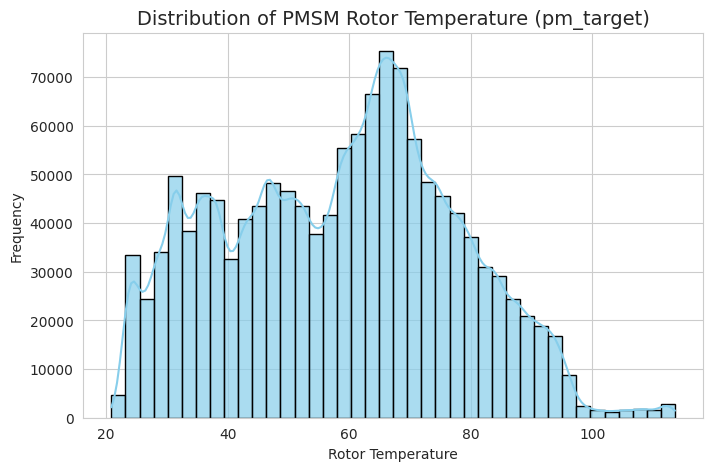

In [ ]:
## visualizing the target variable

# Set seaborn style
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

sns.histplot(
    data['pm_target'],
    bins=40,
    kde=True,          # adds smooth density overlay line
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

plt.title("Distribution of PMSM Rotor Temperature (pm_target)", fontsize=14)
plt.xlabel("Rotor Temperature")
plt.ylabel("Frequency")

plt.show()

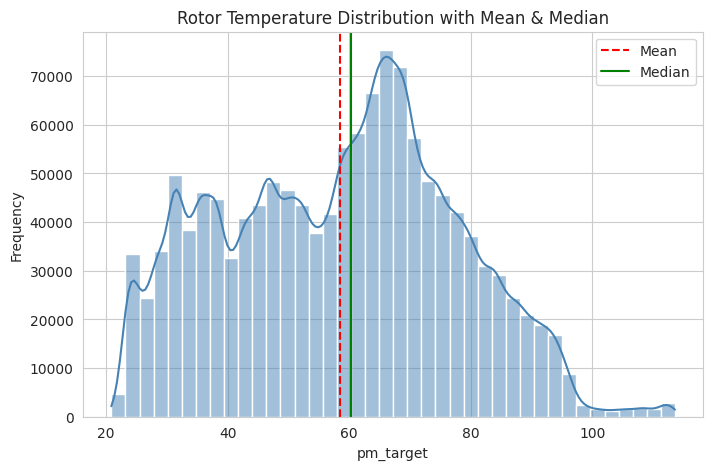

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(data['pm_target'], bins=40, kde=True, color='steelblue')

plt.axvline(data['pm_target'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(data['pm_target'].median(), color='green', linestyle='-', label='Median')

plt.title("Rotor Temperature Distribution with Mean & Median")
plt.xlabel("pm_target")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [ ]:
## Data overview

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330816 entries, 0 to 1330815
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   u_q             1330816 non-null  float64
 1   coolant         1330816 non-null  float64
 2   stator_winding  1330816 non-null  float64
 3   u_d             1330816 non-null  float64
 4   stator_tooth    1330816 non-null  float64
 5   motor_speed     1330816 non-null  float64
 6   i_d             1330816 non-null  float64
 7   i_q             1330816 non-null  float64
 8   stator_yoke     1330816 non-null  float64
 9   ambient         1330816 non-null  float64
 10  torque          1330816 non-null  float64
 11  pm_target       1330816 non-null  float64
dtypes: float64(12)
memory usage: 121.8 MB


In [ ]:
## Descriptive statistics

data.describe()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,stator_yoke,ambient,torque,pm_target
count,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06
mean,5.427900e+01,3.622999e+01,6.634275e+01,-2.513381e+01,5.687858e+01,2.202081e+03,-6.871681e+01,3.741278e+01,4.818796e+01,2.456526e+01,3.110603e+01,5.850678e+01
std,4.417323e+01,2.178615e+01,2.867206e+01,6.309197e+01,2.295223e+01,1.859663e+03,6.493323e+01,9.218188e+01,1.999100e+01,1.929522e+00,7.713575e+01,1.900150e+01
min,-2.529093e+01,1.062375e+01,1.858582e+01,-1.315304e+02,1.813398e+01,-2.755491e+02,-2.780036e+02,-2.934268e+02,1.807669e+01,8.783478e+00,-2.464667e+02,2.085696e+01
25%,1.206992e+01,1.869814e+01,4.278796e+01,-7.869090e+01,3.841601e+01,3.171107e+02,-1.154061e+02,1.095863e+00,3.199033e+01,2.318480e+01,-1.374265e-01,4.315158e+01
50%,4.893818e+01,2.690014e+01,6.511013e+01,-7.429755e+00,5.603635e+01,1.999977e+03,-5.109376e+01,1.577401e+01,4.562551e+01,2.479733e+01,1.086035e+01,6.026629e+01
75%,9.003439e+01,4.985749e+01,8.814114e+01,1.470271e+00,7.558668e+01,3.760639e+03,-2.979688e+00,1.006121e+02,6.146083e+01,2.621702e+01,9.159718e+01,7.200837e+01
max,1.330370e+02,1.015985e+02,1.413629e+02,1.314698e+02,1.119464e+02,6.000015e+03,5.189670e-02,3.017079e+02,1.011480e+02,3.071420e+01,2.610057e+02,1.136066e+02


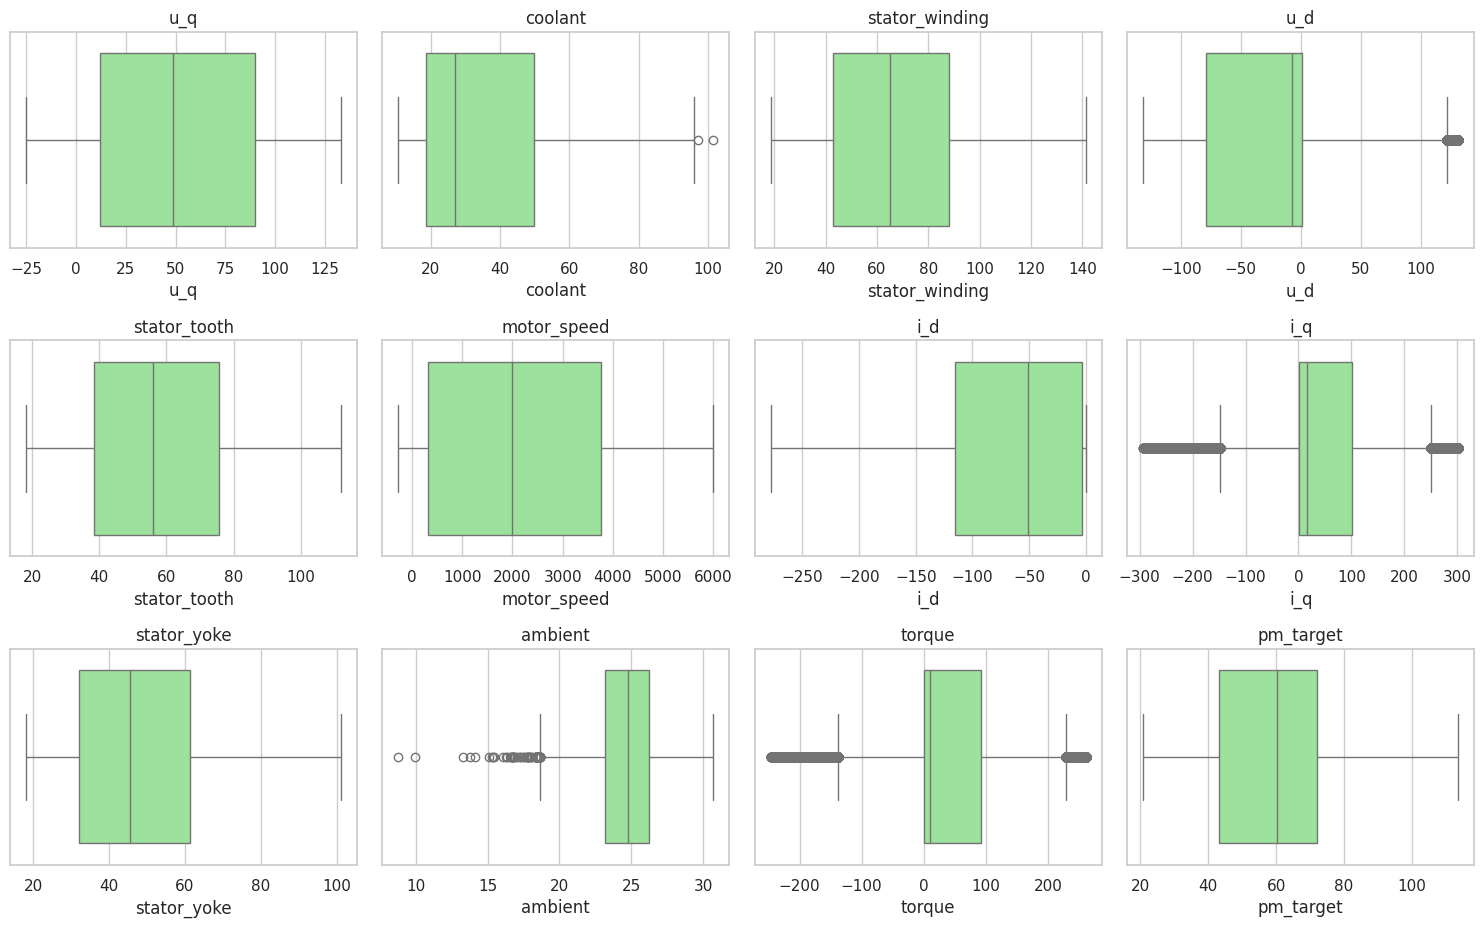

In [ ]:
## Outlier detection and handling

sns.set(style="whitegrid")

cols = data.columns
plt.figure(figsize=(15,12))

for i, col in enumerate(cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(x=data[col], color="lightgreen")
    plt.title(col)

plt.tight_layout()
plt.show()

## the target variable doesn't have outliers . features do have which can reflect certain anomalies/spikes.

#### Feature Engineering

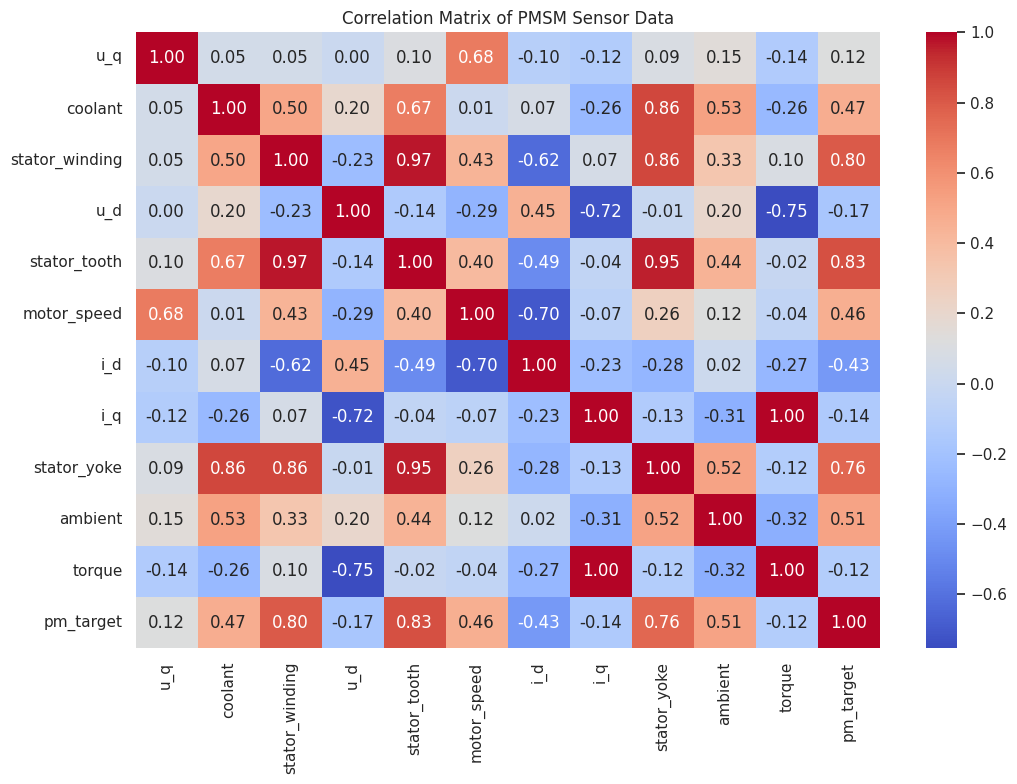

In [ ]:
## correlation analysis

plt.figure(figsize=(12,8))

corr = data.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of PMSM Sensor Data")
plt.show()

## the features are in good corelation with the target variable.

In [ ]:
##feature scaling.

from sklearn.preprocessing import StandardScaler
scaler =  StandardScaler()

scaled_data = scaler.fit_transform(data)

#convert back into dataframe
scaled_data = pd.DataFrame(scaled_data, columns = data.columns)

#### Model Training

##### a) Isolation Forest Model

In [ ]:
## Isolation Forest Model

from sklearn.ensemble import IsolationForest
model = IsolationForest(n_estimators=100,contamination=0.2,random_state=42) # setting the hyper-parameters

model.fit(scaled_data) # fitting the model

IsolationForest(contamination=0.2, random_state=42)

In [ ]:
## Predicting anomalies in the datasets

pred = model.predict(scaled_data)

In [ ]:
## Add predictions as a new column
scaled_data['anomally'] = pred

In [ ]:
scaled_data['anomally'].value_counts()

### Deduction : 1 -> normal ; -1 -> Anomally


,count
anomally,
1,1064653
-1,266163


In [ ]:
## Convert anomaly labels
scaled_data['anomally'] = scaled_data['anomally'].map({1:0, -1:1})

## Count anomalies
print("\nNumber of anomalies detected:")
print(scaled_data['anomally'].value_counts())  ## Deduction: 1-> Anomally


Number of anomalies detected:
anomally
0    1064653
1     266163
Name: count, dtype: int64


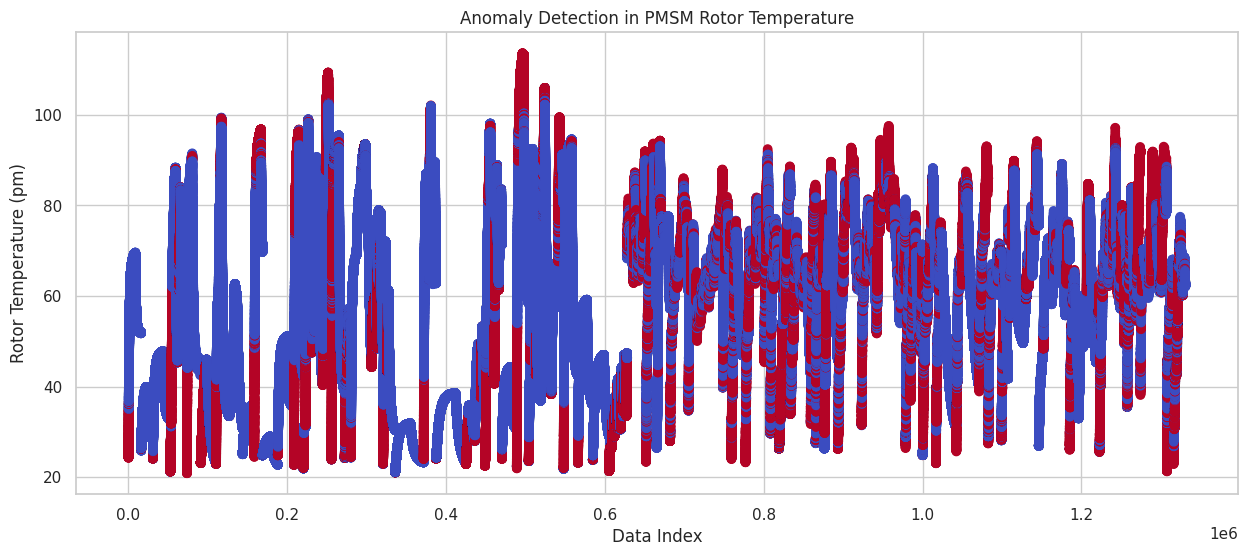

In [ ]:
## Visualizing the anomallies

plt.figure(figsize=(15,6))

plt.scatter(
    data.index,
    data['pm_target'],
    c=scaled_data['anomally'],
    cmap='coolwarm'
)

plt.title("Anomaly Detection in PMSM Rotor Temperature")
plt.xlabel("Data Index")
plt.ylabel("Rotor Temperature (pm)")
plt.show()

**From typical anomaly plots with Isolation Forest:**

🔵 **Blue points** → Normal operating conditions

🔴 **Red points** → Detected anomalies

The model marks points as anomalies when they deviate significantly from normal patterns in the multidimensional feature space.



---
Red points appear throughout the dataset, not just at extreme temperatures.

**This means anomalies are not just high temperature spikes, but unusual combinations of sensor readings**, such as:

  1.abnormal current (i_d, i_q)

  2.abnormal voltage (u_d, u_q)

unexpected torque vs speed relationship


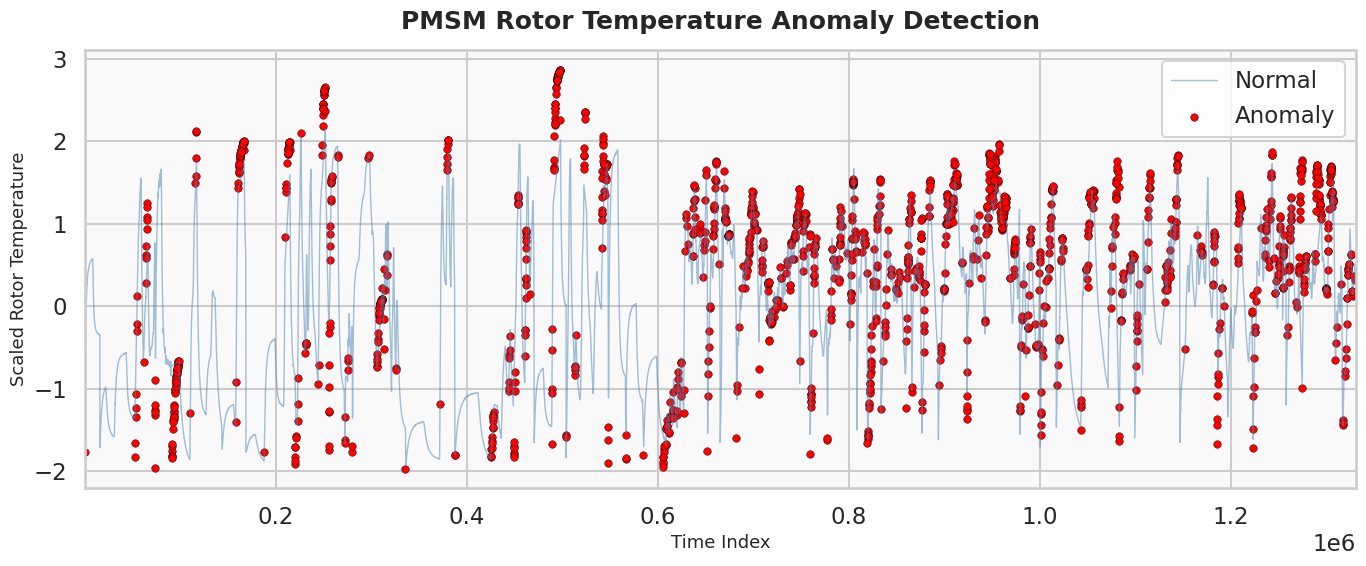

In [ ]:
# ===============================
# Seaborn Global Theme
# ===============================
sns.set_theme(
    style="whitegrid",        # background grid style
    palette="mako",           # modern color palette
    context="talk"            # good for presentations
)

# ===============================
# Sample data (optional)
# ===============================
# If dataset is huge, sample it for better visualization
sample_data = scaled_data.sample(8000)

# Separate anomalies
anomalies = sample_data[sample_data['anomally'] == 1]
normal = sample_data[sample_data['anomally'] == 0]

# ===============================
# Create Figure
# ===============================
plt.figure(figsize=(14,6))

# Background color
plt.gca().set_facecolor("#f9f9f9")
plt.gcf().patch.set_facecolor("#ffffff")

# ===============================
# Plot Normal Temperature Trend
# ===============================
sns.lineplot(
    x=normal.index,
    y=normal['pm_target'],
    color="steelblue",
    linewidth=1,
    alpha=0.5,
    label="Normal"
)

# ===============================
# Plot Anomaly Points
# ===============================
sns.scatterplot(
    x=anomalies.index,
    y=anomalies['pm_target'],
    color="red",
    s=30,
    edgecolor="black",
    linewidth=0.3,
    label="Anomaly"
)

# ===============================
# Labels and Title
# ===============================
plt.title(
    "PMSM Rotor Temperature Anomaly Detection",
    fontsize=18,
    weight="bold",
    pad=15
)

plt.xlabel("Time Index", fontsize=13)
plt.ylabel("Scaled Rotor Temperature", fontsize=13)

# ===============================
# Improve Layout
# ===============================
plt.legend(frameon=True)
plt.margins(x=0)
plt.tight_layout()

# ===============================
# Show Plot
# ===============================
plt.show()

In [ ]:
## Save the anomallies for further visualization.

## Save anomalies
anomalies = data[scaled_data['anomally'] == 1]
anomalies.to_csv("detected_anomalies.csv", index=False)

print("\nAnomaly records saved to detected_anomalies.csv")


Anomaly records saved to detected_anomalies.csv


The **csv file saved contains the points which were identified as anomallies**. This helps the maintenance department in the industry or factory to monitor the machine and take necessary steps.

##### b) Decission Tree Model

**Use the prediction of isolation forest model to train the decission tree models**


*  Isolation Forest → detect anomalies
*  Decision Tree → learn rules explaining anomalies



In [ ]:
## the labelled dataset

scaled_data.head()

## Data is already scaled and cleaned and ready for modelling.

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,stator_yoke,ambient,torque,pm_target,anomally
0,-1.238979,-0.799812,-1.648158,0.392820,-1.681117,-1.184128,1.058337,-0.405855,-1.494244,-2.443386,-0.400838,-1.786837,0
1,-1.236150,-0.799197,-1.647959,0.393521,-1.681047,-1.184129,1.058278,-0.405867,-1.494323,-2.443396,-0.400082,-1.787686,0
2,-1.238757,-0.798729,-1.648064,0.392464,-1.681078,-1.184128,1.058289,-0.405854,-1.493755,-2.443404,-0.400974,-1.787338,0
3,-1.236180,-0.798417,-1.648285,0.393356,-1.681146,-1.184126,1.058270,-0.405836,-1.493529,-2.443409,-0.400174,-1.786847,0
4,-1.239442,-0.797432,-1.648303,0.393101,-1.681195,-1.184127,1.057279,-0.405455,-1.493738,-2.443413,-0.400565,-1.786248,0


In [ ]:
## target variavle -> anomally
scaled_data['anomally'].value_counts()

,count
anomally,
0,1064653
1,266163


In [ ]:
scaled_data.shape

(1330816, 13)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [ ]:
## Splitting the data

# Features
X = scaled_data.drop("anomally", axis=1)

# Target
y = scaled_data["anomally"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
## Train decision tree
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
## Model Evaluation

from sklearn.metrics import classification_report

pred = tree_model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96    212973
           1       0.94      0.71      0.81     53191

    accuracy                           0.93    266164
   macro avg       0.93      0.85      0.88    266164
weighted avg       0.93      0.93      0.93    266164



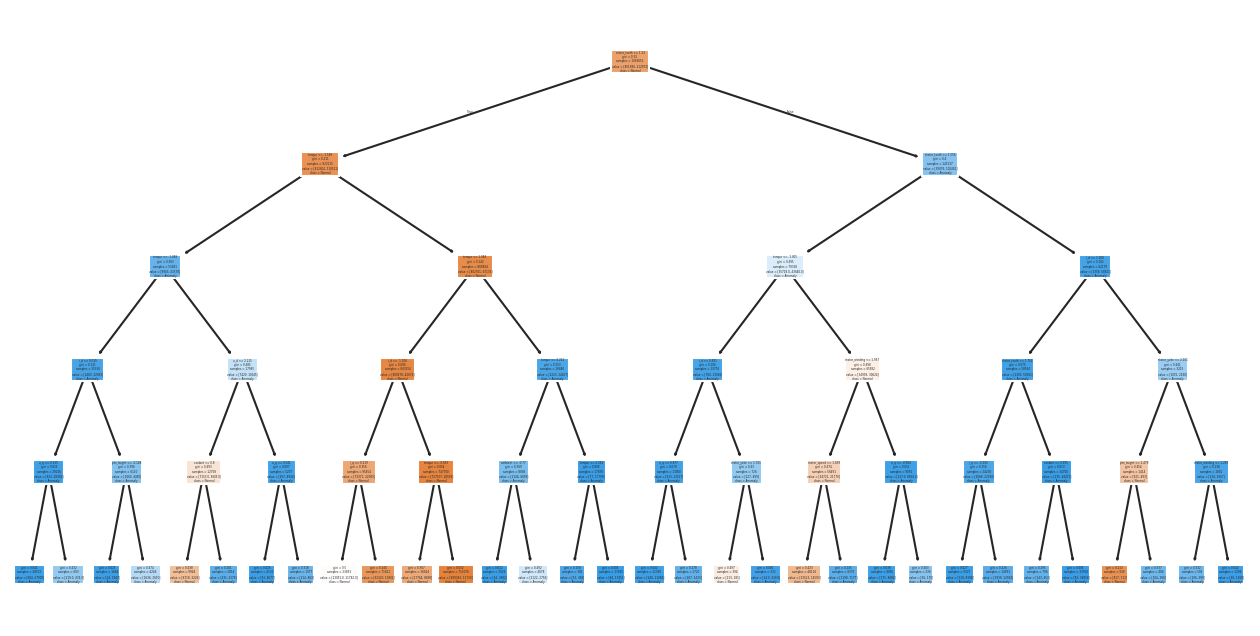

In [ ]:
## Visualizing the tree to get the features affecting the most to anomally.
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Normal","Anomaly"],
    filled=True
)

plt.show()

In [ ]:
feature_importance = pd.Series(
    tree_model.feature_importances_,
    index=X.columns  ## X - feature data frame.(refer data split cell )
)

print(feature_importance.sort_values(ascending=False))

torque            0.450358
stator_tooth      0.429736
i_d               0.035169
stator_winding    0.023258
i_q               0.019410
motor_speed       0.018661
u_d               0.008188
coolant           0.005288
ambient           0.003415
pm_target         0.002730
stator_yoke       0.002632
u_q               0.001155
dtype: float64


From the feature importance analysis, torque and stator_motor are identified as the most significant features for the Decision Tree model.

#### **Result Analysis**

The **anomaly detection was performed using Isolation Forest**, which successfully identified unusual patterns in the motor sensor dataset. Visualization of the results highlighted observations with abnormal operating conditions. A **Decision Tree model was then used to interpret these anomalies**. Feature importance analysis showed that torque and stator_motor temperature were key factors influencing abnormal behavior.



---


#### **Significance**

This approach demonstrates how machine learning can effectively detect abnormal motor operating conditions. Early detection of such anomalies can help improve equipment reliability, support predictive maintenance, and reduce operational failures in industrial systems.


---


#### **Conclusion**

The **study shows that combining Isolation Forest with interpretable models like Decision Tree helps detect and explain anomalies in motor sensor data**. The results highlight the importance of key sensor features and demonstrate the usefulness of data-driven methods for industrial monitoring and fault detection.